# MVTec AD — Data Exploration
Sanity check for the dataloader. Run after `python scripts/download_mvtec.py`.

In [7]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import torch
from pathlib import Path
from data.mvtec import MVTecDataset
from utils.seed import seed_everything

seed_everything(42)

In [16]:
DATA_ROOT = Path('../data/mvtec')
print(f'Categories: {[d.name for d in DATA_ROOT.iterdir() if d.is_dir()]}')
CATEGORY  = 'grid'

train_ds = MVTecDataset(DATA_ROOT, CATEGORY, 'train')
val_ds   = MVTecDataset(DATA_ROOT, CATEGORY, 'val')
test_ds  = MVTecDataset(DATA_ROOT, CATEGORY, 'test')

print(f'Train : {len(train_ds)} samples')
print(f'Val   : {len(val_ds)} samples')
print(f'Test  : {len(test_ds)} samples')

Categories: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
Train : 264 samples
Val   : 15 samples
Test  : 63 samples


Categories: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
bottle: 209 images
cable: 224 images
capsule: 219 images
carpet: 280 images
grid: 264 images
hazelnut: 391 images
leather: 245 images
metal_nut: 220 images
pill: 267 images
screw: 320 images
tile: 230 images
toothbrush: 60 images
transistor: 213 images
wood: 247 images
zipper: 240 images


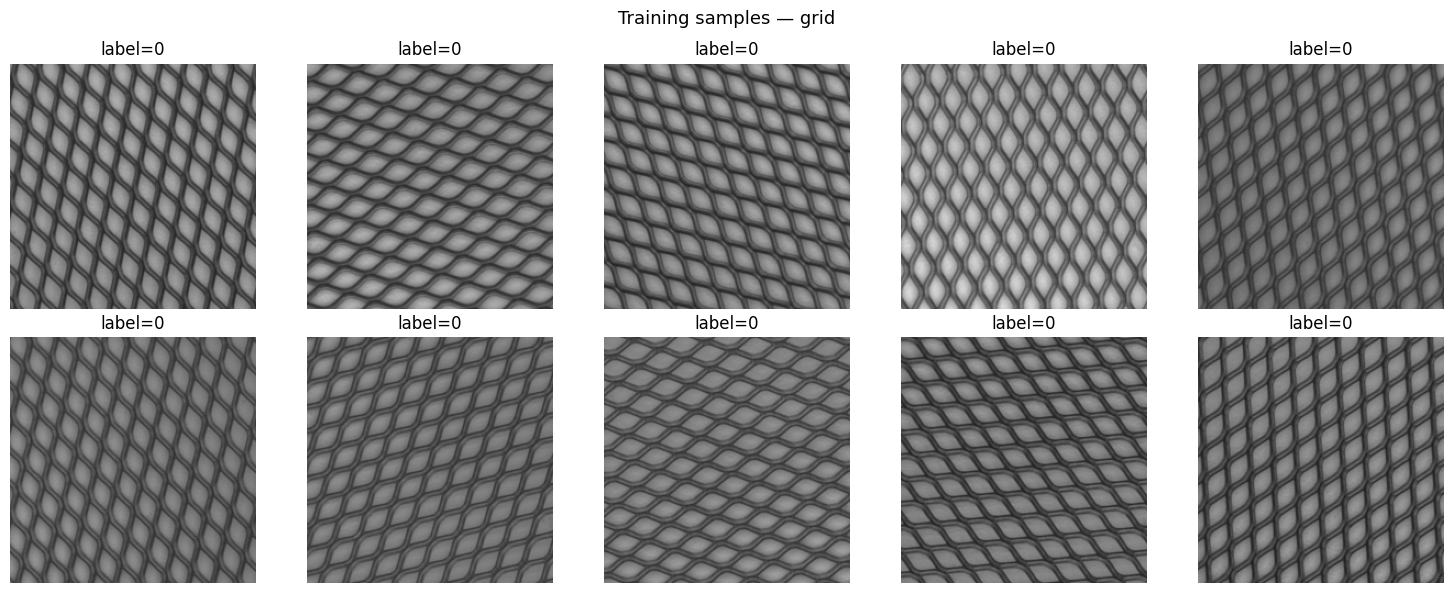

In [22]:
categories = [d.name for d in DATA_ROOT.iterdir() if d.is_dir()]
print(f'Categories: {categories}')

for category in categories:
    train_dir = DATA_ROOT / category / 'train'
    image_paths = list(train_dir.rglob('*.png'))
    print(f'{category}: {len(image_paths)} images')

# Visualize 10 samples from the selected category
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Training samples — {CATEGORY}', fontsize=13)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(t):
    return (t * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

for i in range(min(10, len(train_ds))):
    item = train_ds[i]
    ax = axes[i // 5, i % 5]
    ax.imshow(denorm(item['image']))
    ax.set_title(f'label={item["label"]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


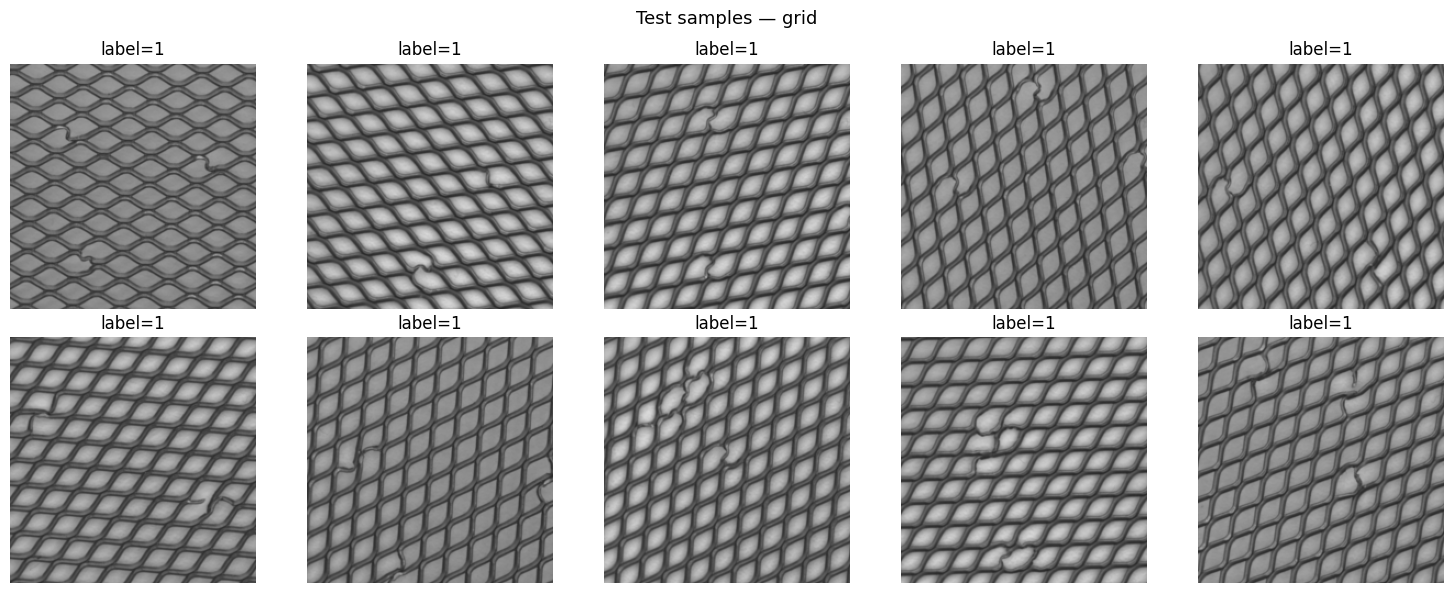

In [23]:
#visulize 10 samples from the test set
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Test samples — {CATEGORY}', fontsize=13)
for i in range(min(10, len(test_ds))):
    item = test_ds[i]
    ax = axes[i // 5, i % 5]
    ax.imshow(denorm(item['image']))
    ax.set_title(f'label={item["label"]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

IndexError: index 2 is out of bounds for axis 0 with size 2

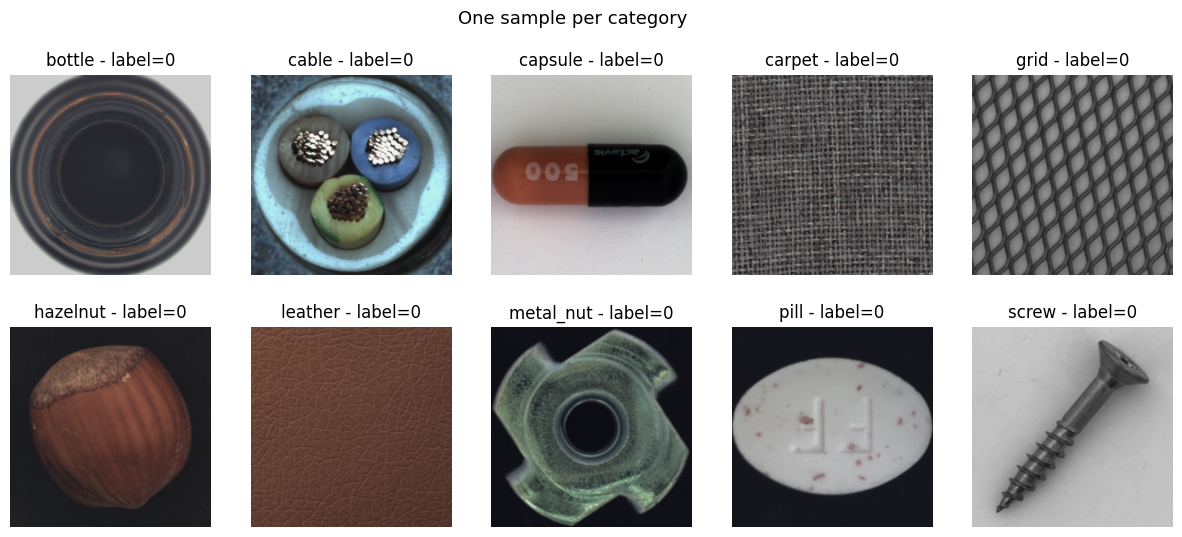

In [ ]:
# visualise 1 sample for each category
n_cols = 5
n_rows = (len(categories) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
fig.suptitle('One sample per category', fontsize=13)

axes = axes.flatten()

for i, category in enumerate(categories):
    ds = MVTecDataset(DATA_ROOT, category, 'train')
    item = ds[0]
    ax = axes[i]
    ax.imshow(denorm(item['image']))
    ax.set_title(f'{category} - label={item["label"]}')
    ax.axis('off')

for ax in axes[len(categories):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


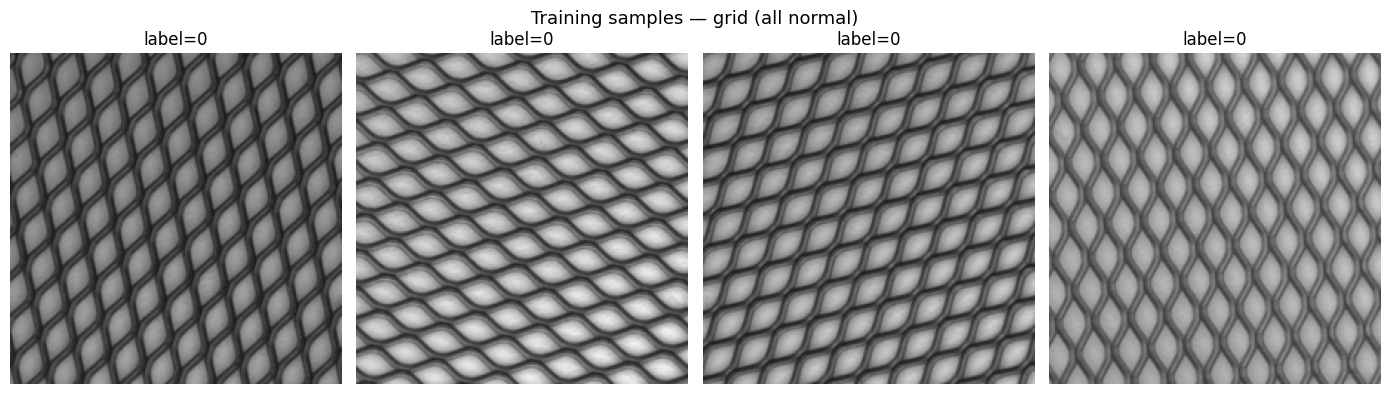

In [11]:
# visualise 4 training samples (all normal)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle(f'Training samples — {CATEGORY} (all normal)', fontsize=13)

# ImageNet de-normalisation for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(t):
    return (t * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

for ax, idx in zip(axes, [0, 1, 2, 3]):
    item = train_ds[idx]
    ax.imshow(denorm(item['image']))
    ax.set_title(f'label={item["label"]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

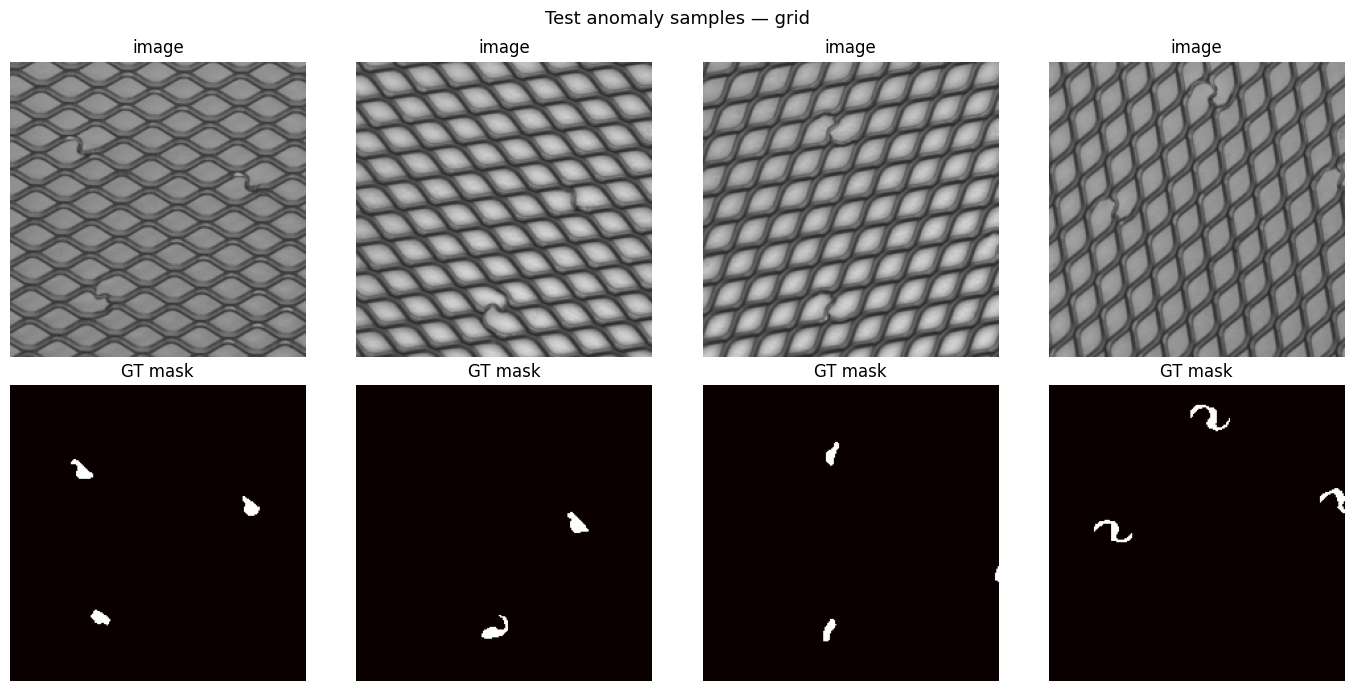

In [12]:
# find an anomaly sample in test and show image + mask side by side
anomaly_items = [test_ds[i] for i in range(len(test_ds)) if test_ds[i]['label'] == 1]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(f'Test anomaly samples — {CATEGORY}', fontsize=13)

for col, item in enumerate(anomaly_items[:4]):
    axes[0, col].imshow(denorm(item['image']))
    axes[0, col].set_title('image')
    axes[0, col].axis('off')
    axes[1, col].imshow(item['mask'].squeeze(), cmap='hot')
    axes[1, col].set_title('GT mask')
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

In [13]:
# class distribution in test set
labels = [test_ds[i]['label'] for i in range(len(test_ds))]
n_normal  = labels.count(0)
n_anomaly = labels.count(1)
print(f'Test set — normal: {n_normal}  anomaly: {n_anomaly}')
print(f'Anomaly rate: {n_anomaly / len(labels):.1%}')

Test set — normal: 17  anomaly: 46
Anomaly rate: 73.0%
